# **Final Model** #

**Name:** Cheukman Zhou  
**Student Number:** 400460952  
**Group:** Group 30  
**Codabench Link:** https://www.codabench.org/competitions/14898/



In [1]:
# Mount Google Drive when running on Colab
try:
    from google.colab import drive

    drive.mount("/content/drive")
    print("Google Drive mounted successfully!")
except ImportError:
    print("Error with mounting.")

Mounted at /content/drive
Google Drive mounted successfully!


In [2]:
# Install required packages
# !pip install transformers datasets scikit-learn torch evaluate accelerate

import random
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_DIR = "/content/drive/MyDrive/input_data" # Running on Colab
# DATA_DIR = str(Path.cwd() / "input_data")
N_TRAIN = 50_000
N_TEST = 5_000

# Yahoo Answers Categories
LABEL_NAMES = [
    "Society & Culture",
    "Science & Mathematics",
    "Health",
    "Education & Reference",
    "Computers & Internet",
    "Sports",
    "Business & Finance",
    "Entertainment & Music",
    "Family & Relationships",
    "Politics & Government",
]
NUM_LABELS = len(LABEL_NAMES)
id2label = {i: name for i, name in enumerate(LABEL_NAMES)}
label2id = {name: i for i, name in enumerate(LABEL_NAMES)}

train_text = pd.read_csv(f"{DATA_DIR}/training_data.csv", nrows=N_TRAIN)
train_lab = pd.read_csv(f"{DATA_DIR}/training_label.csv", nrows=N_TRAIN)
train_df = train_text.copy()
train_df["label"] = train_lab["class_index"].astype(int) - 1


testing_5k = pd.read_csv(f"{DATA_DIR}/testing_data.csv", nrows=N_TEST)
test_lab = pd.read_csv(f"{DATA_DIR}/testing_label.csv", nrows=N_TEST)
test_df = testing_5k.copy()
test_df["label"] = test_lab["class_index"].astype(int) - 1
print(f"Eval metrics: first {N_TEST} rows of testing_data.csv + testing_label.csv")

display(train_df.head())
display(test_df.head())

Eval metrics: first 5000 rows of testing_data.csv + testing_label.csv


,question_title,question_content,label
0,why doesn't an optical mouse work on a glass t...,or even on some surfaces?,4
1,What is the best off-road motorcycle trail ?,long-distance trail throughout CA,5
2,What is Trans Fat? How to reduce that?,I heard that tras fat is bad for the body. Wh...,2
3,How many planes Fedex has?,I heard that it is the largest airline in the ...,6
4,"In the san francisco bay area, does it make se...",the prices of rent and the price of buying doe...,6


,question_title,question_content,label
0,What makes friendship click?,How does the spark keep going?,8
1,Why does Zebras have stripes?,What is the purpose or those stripes? Who do t...,1
2,What did the itsy bitsy sipder climb up?,NaN,3
3,What is the difference between a Bachelors and...,NaN,3
4,Why do women get PMS?,NaN,2


In [4]:
MODEL_1_NAME = "bert-base-uncased"

tokenizer_1 = AutoTokenizer.from_pretrained(MODEL_1_NAME)
model_1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_1_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
)

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [5]:
def format_question_text(title, content):
    return f"Title: {title}\nContent: {content}"


def tokenize_fn_model1(examples):
    texts = [
        format_question_text(t, c)
        for t, c in zip(examples["question_title"], examples["question_content"])
    ]
    enc = tokenizer_1(
        texts,
        truncation=True,
        max_length=512,
        padding=False,
    )
    if "label" in examples:
        enc["labels"] = [int(x) for x in examples["label"]]
    return enc


train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
eval_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

tokenized_train_1 = train_ds.map(
    tokenize_fn_model1,
    batched=True,
    remove_columns=train_ds.column_names,
)
tokenized_eval_1 = eval_ds.map(
    tokenize_fn_model1,
    batched=True,
    remove_columns=eval_ds.column_names,
)

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [6]:
def compute_metrics_model1(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": float(accuracy_score(labels, preds)),
        "f1": float(f1_score(labels, preds, average="weighted")),
    }


data_collator_1 = DataCollatorWithPadding(tokenizer=tokenizer_1)

training_args_1 = TrainingArguments(
    output_dir="./outputs_model_1_yahoo_topics",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to="none",
)

trainer_1 = Trainer(
    model=model_1,
    args=training_args_1,
    train_dataset=tokenized_train_1,
    eval_dataset=tokenized_eval_1,
    processing_class=tokenizer_1,
    data_collator=data_collator_1,
    compute_metrics=compute_metrics_model1,
)

trainer_results_1 = trainer_1.train()

eval_metrics = trainer_1.evaluate()
print("Results: ", eval_metrics)

pred_out = trainer_1.predict(tokenized_eval_1)
y_true = test_df["label"].to_numpy()
y_pred = np.argmax(pred_out.predictions, axis=-1)
print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(NUM_LABELS)),
        target_names=LABEL_NAMES,
        digits=2,
        zero_division=0,
    )
)

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.887857,0.940126,0.685400,0.676812
2,0.778453,0.964716,0.688800,0.683059
3,0.520641,1.132737,0.682400,0.677135
4,0.492386,1.439474,0.677600,0.675153
5,0.254113,1.680470,0.671000,0.669766


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Results:  {'eval_loss': 0.9668920040130615, 'eval_accuracy': 0.689, 'eval_f1': 0.6831957064002857, 'eval_runtime': 11.3328, 'eval_samples_per_second': 441.199, 'eval_steps_per_second': 55.15, 'epoch': 5.0}
                        precision    recall  f1-score   support

     Society & Culture       0.63      0.42      0.50       354
 Science & Mathematics       0.71      0.76      0.74       584
                Health       0.68      0.81      0.74       385
 Education & Reference       0.52      0.42      0.47       434
  Computers & Internet       0.81      0.86      0.83       622
                Sports       0.86      0.89      0.87       330
    Business & Finance       0.60      0.59      0.59      1202
 Entertainment & Music       0.69      0.71      0.70       330
Family & Relationships       0.71      0.80      0.75       355
 Politics & Government       0.76      0.76      0.76       404

              accuracy                           0.69      5000
             macro avg  

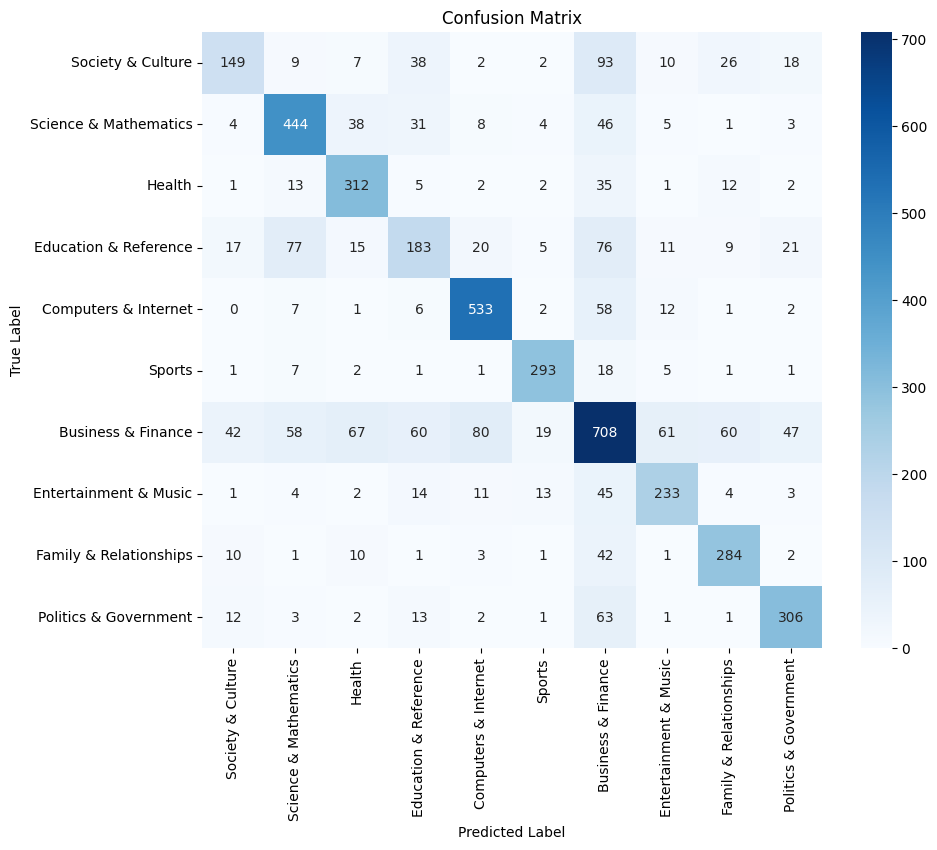

In [7]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()